In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

In [4]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_granularity(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for)
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(n_threads[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'thread (worker)',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='assemble seq'),
        Patch(facecolor='blue', label='assemble parallel')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.63, 0.9, f"threadpool: size_queue({size_queue})\nnodi : {nodi}\nruns: {len(data_for)}\nn_job: {kk}*n_worker (+1)", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [5]:
def plot_speedup_granularity(data_list,title,gran,n_threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(gran))
    speedup2 = np.zeros(len(gran))


    for i in range(len(gran)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        speedup2[i] = data_mean[1]/data_mean[i+1]
        

    #print(data_list)
    #print(data_mean)
    gran = gran[::-1]
    speedup = speedup[::-1]
    speedup2 = speedup2[::-1]
    ax.plot(gran,speedup,'o--')
    ax.plot(gran,speedup2,'o--')

    ax.legend(['speedup w.r.t. sequential','speedup2 w.r.t. threadpool sequetial'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(gran)
    ax.set_xticklabels(gran, rotation = 45)


    ax.set(xlabel = 'workers (thread)',ylabel = 'speedup')
    plt.figtext(0.7, 0.9, f"threadpool: size_queue({size_queue})\nnodi: {nodi}\nruns: {len(data_list[0])}\nn_job: {kk}*n_worker (+1)", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

## assemblaggio sparse matrix da triple

metti cronometro in fe bilinear form assembler 

auto start = std::chrono::high_resolution_clock::now();

auto end = std::chrono::high_resolution_clock::now();
auto duration = std::chrono::duration_cast<std::chrono::microseconds>(end - start);  
std::cout<<duration.count()<<",";

100 500 1000

In [6]:
#a mano settali uguali a come runnato in cluster 
#set parameter
nodi = 1000 #costo singola iterazione
n_threads = [1,2,3,4,5,6,7,8]
size_queue = 1000 #hardcome in codice ma qui non conta
kk = 1 # n_job = kk*num_worker (+1)

In [ ]:
#run manualmente seq, nodi
!./run_sparsematrix.sh 100

terminate called after throwing an instance of 'std::logic_error'
  what():  basic_string: construction from null is not valid
./run_assemble.sh: line 11: 12488 Aborted                 (core dumped) ./"test_assemble" "$2" >> "$output_file"


In [7]:
dati_assemble = []
dati_assemble = np.genfromtxt("test_sparsematrix_nodi"+str(nodi)+".txt",delimiter=',',dtype=int)[:-1]

In [ ]:
#run manualmente parallel, nodi thread kk (vedi run.sh per def kk)
!./run_sparsematrix_parallel.sh 100 2 10

In [8]:

dati_assemble_parallel = []
for i,nb in enumerate(n_threads):
    dati_assemble_parallel.append(np.genfromtxt("test_sparsematrix_nodi"+str(nodi)+"_thread"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

In [ ]:
#run manualmente parallel, nodi thread kk (vedi run.sh per def kk)
!./run_sparsematrix_unicovettore_parallel.sh 100 2 10

In [9]:
dati_assemble_unicovettore_parallel = []
for i,nb in enumerate(n_threads):
    dati_assemble_unicovettore_parallel.append(np.genfromtxt("test_sparsematrix_unicovettore_nodi"+str(nodi)+"_thread"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

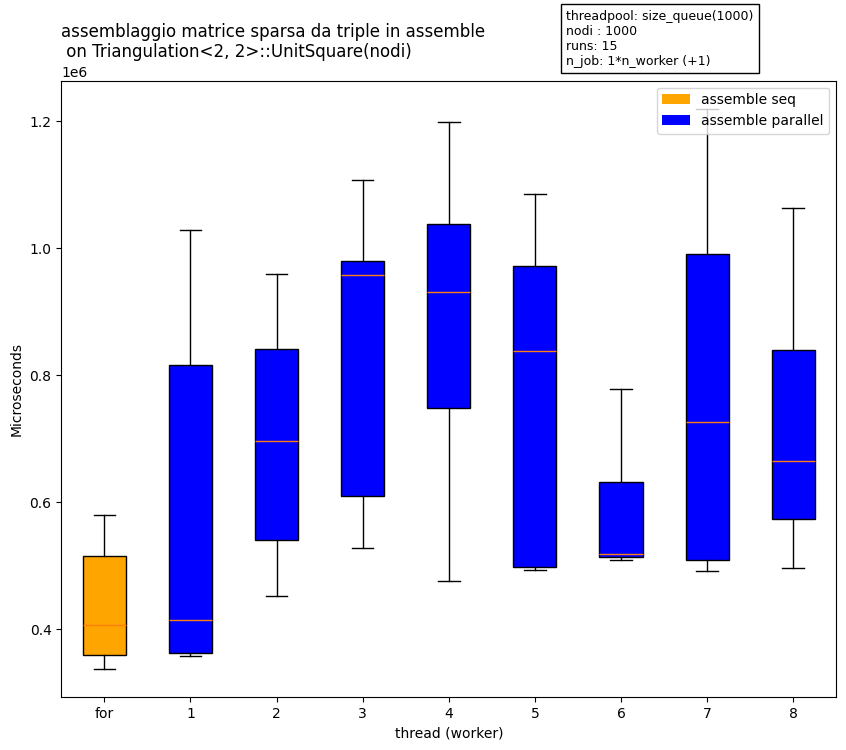

In [11]:
plot_granularity(dati_assemble, dati_assemble_parallel,"assemblaggio matrice sparsa da triple in assemble \n on Triangulation<2, 2>::UnitSquare(nodi)")

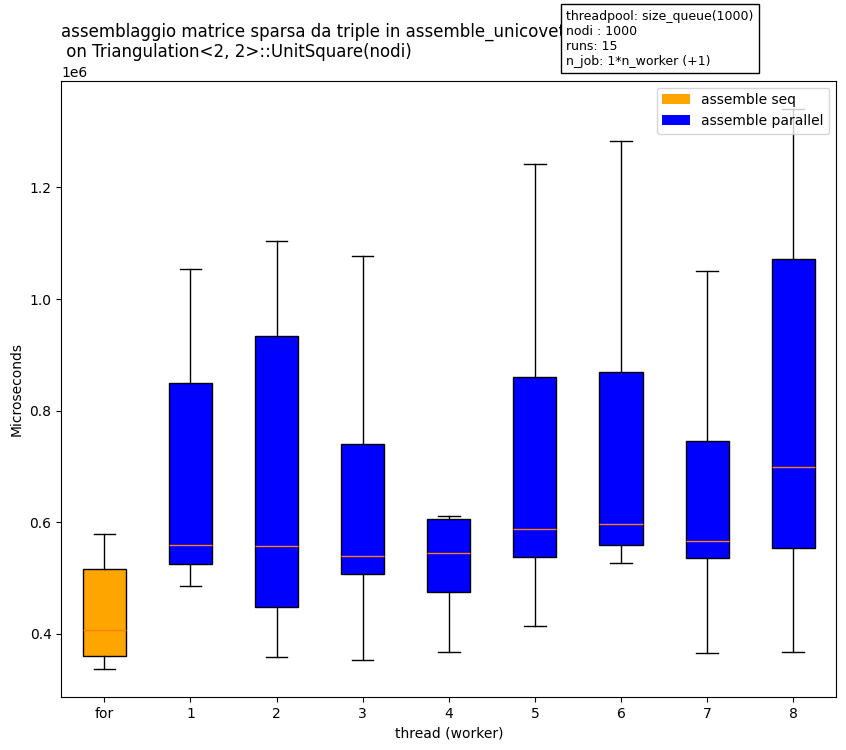

In [10]:
plot_granularity(dati_assemble, dati_assemble_unicovettore_parallel,"assemblaggio matrice sparsa da triple in assemble_unicovettore \n on Triangulation<2, 2>::UnitSquare(nodi)")

/mnt/c/Users/Cosimo Solidoro/Desktop/ProgettoPacs/plot/plot_assemble/calcolo_triple_assemble3/boxplot_calcolotriple_OptO3_assemble3_nodi500